# Calibration (host noise-floor) -- CS-01 TAS

**Purpose**: characterise the per-host noise floor that every `experiment` run depends on. Four probes -- timer resolution, scheduling jitter, loopback latency, empty-handler scaling -- produce one JSON envelope that `05-experimental.ipynb` and `06-yoly-experimental.ipynb` reference when reporting measured latencies.

**Inputs**: none. Host identity (hostname, OS, CPU count, RAM) is snapshotted at runtime.

**Outputs**:
- `data/results/experiment/calibration/<host>_<YYYYMMDD_HHMMSS>.json` -- the full calibration envelope.
- `data/img/experiment/calibration/dashboard.{png,svg}` -- 2x2 summary card (timer / jitter / loopback / handler scaling).
- `data/img/experiment/calibration/scaling.{png,svg}` -- standalone empty-handler scaling line plot.

**Equivalent CLI**:
```bash
python src/scripts/calibration.py
```

**How to use the baseline**: every measured experiment latency on this host should be reported as:

```
reported = measured_us - loopback.median_us  +/- jitter.p99_us
```

i.e. subtract the loopback median (host overhead), report the jitter p99 as the uncertainty band. Any measured value below `loopback.median_us` is an instrument error, not a real service. Full plan + checkpoint log in [notes/calibration.md](notes/calibration.md).

This notebook is thin: all logic lives in `src.scripts.calibration` and `src.view.calibration`. The cells below just call `run()` and display.

In [1]:
%matplotlib inline
from pathlib import Path

import pandas as pd

from src.scripts.calibration import run
from src.view import plot_calib_dashboard, plot_calib_scaling

_IMG_ROOT = Path("data/img/experiment/calibration")

## 1. Run the four probes

`run()` executes under `winmm.timeBeginPeriod(1)` on Windows (no-op elsewhere). Default sample counts take ~60-90 s on a 16-core laptop; tune via keyword args if needed (e.g. `jitter_samples=500, loopback_samples=500, per_worker=20, concurrency=(1, 10)` for a ~8 s smoke).

The envelope is written to `data/results/experiment/calibration/<host>_<timestamp>.json` and returned in-memory for the display cells below.

In [2]:
_envelope = run(write=True, verbose=True)
print(f"\nwrote: {_envelope.get('output_path')}")

  [1/4] timer resolution ...
  [2/4] scheduling jitter ...
  [3/4] loopback latency ...
  [4/4] empty-handler scaling ...
      c=     1  running 500 requests ...
      c=     1  done in 1.0s  median=1826.9us  p99=3828.3us
      c=    10  running 500 requests ...
      c=    10  done in 1.2s  median=14699.5us  p99=114702.2us
      c=    50  running 500 requests ...
      c=    50  done in 1.4s  median=90432.5us  p99=475884.9us
      c=   100  running 500 requests ...
      c=   100  done in 1.4s  median=128032.1us  p99=835165.4us
      c=   200  running 400 requests ...
      c=   200  done in 1.7s  median=360066.9us  p99=1569974.2us
      c=   500  running 500 requests ...
      c=   500  done in 2.4s  median=1274448.6us  p99=2290291.6us
      c=  1000  running 1000 requests ...
      c=  1000  done in 4.8s  median=1492740.9us  p99=4519876.6us
      c=  5000  running 5000 requests ...
      c=  5000  done in 22.3s  median=5477952.3us  p99=21477958.2us
      c=  8000  running 8000 requ

## 2. Host profile

The machine the rest of the calibration was measured against. Record thermals / background load conditions in [notes/devlog.md](notes/devlog.md) when benching formally.

In [3]:
_host = _envelope["host_profile"]
pd.Series({
    "hostname": _host.get("hostname"),
    "os": _host.get("os"),
    "python": f"{_host.get('python')} ({_host.get('python_impl')})",
    "cpu_count": _host.get("cpu_count"),
    "cpu_machine": _host.get("cpu_machine"),
    "ram_total_gb": round(float(_host.get("ram_total_gb") or 0), 2),
    "timestamp": _envelope.get("timestamp"),
    "elapsed_s": _envelope.get("elapsed_s"),
}, name="value")

hostname                  DESKTOP-INKGBK6
os              Windows-11-10.0.26200-SP0
python                  3.12.10 (CPython)
cpu_count                              16
cpu_machine                         AMD64
ram_total_gb                        63.75
timestamp             2026-04-23T19:38:02
elapsed_s                         208.932
Name: value, dtype: object

## 3. Probe summary tables

Each probe reports a distribution summary. Acronyms expanded below:

- **min** -- minimum observed value; for `timer` this is the actual clock resolution.
- **median / p50** -- 50th percentile (half the samples are faster, half slower).
- **mean** -- arithmetic mean.
- **p95 / p99** -- 95th / 99th percentile (worst-case tail behaviour).
- **max** -- single worst sample.
- **std** -- standard deviation (dispersion).
- **ns** -- nanoseconds (10^-9 s).  **us** -- microseconds (10^-6 s).

In [4]:
_timer = _envelope.get("timer", {})
_jitter = _envelope.get("jitter", {})
_loopback = _envelope.get("loopback", {})

pd.DataFrame({
    "timer [ns]": {
        "min": _timer.get("min_ns"),
        "median / p50": _timer.get("median_ns"),
        "mean": _timer.get("mean_ns"),
        "std": _timer.get("std_ns"),
    },
    "jitter [us]": {
        "mean": _jitter.get("mean_us"),
        "median / p50": _jitter.get("p50_us"),
        "p99": _jitter.get("p99_us"),
        "max": _jitter.get("max_us"),
    },
    "loopback [us]": {
        "min": _loopback.get("min_us"),
        "median / p50": _loopback.get("median_us"),
        "p95": _loopback.get("p95_us"),
        "p99": _loopback.get("p99_us"),
    },
}).round(2)

,timer [ns],jitter [us],loopback [us]
min,100.00,NaN,1139.20
median / p50,100.00,618.20,1733.25
mean,157.73,610.48,NaN
std,714.43,NaN,NaN
p99,NaN,1117.13,3255.05
max,NaN,1622.60,NaN
p95,NaN,NaN,2709.11


## 4. Handler scaling table

Empty `/ping` endpoint, keep-alive, measured at increasing in-flight request counts. Growing gap between `c=1` and `c=10` indicates how much the FastAPI event loop queues when concurrent requests stack up -- often the real cause of prototype degradation at high rates.

In [5]:
_handler = _envelope.get("handler_scaling", {})
_rows = []
for _c, _stats in sorted(_handler.items(), key=lambda _p: int(_p[0])):
    _rows.append({
        "concurrency": int(_c),
        "min [us]": _stats.get("min_us"),
        "median / p50 [us]": _stats.get("median_us"),
        "p95 [us]": _stats.get("p95_us"),
        "p99 [us]": _stats.get("p99_us"),
        "samples": _stats.get("samples"),
    })
pd.DataFrame(_rows).set_index("concurrency").round(1)

,min [us],median / p50 [us],p95 [us],p99 [us],samples
concurrency,,,,,
1,1354.8,1827.0,2836.8,3828.3,500
10,2325.0,14699.6,39709.3,114702.2,500
50,1986.5,90432.5,349495.5,475884.9,500
100,2751.4,128032.1,626699.1,835165.4,500
200,5837.6,360066.9,1427015.2,1569974.2,400
500,346917.6,1274448.6,2158158.0,2290291.6,500
1000,673193.3,1492740.9,4359446.4,4519876.6,500
5000,4422287.6,5477952.3,21329615.6,21477958.2,500
8000,20914106.0,24498506.4,26423334.9,26850063.1,500


## 5. Calibration dashboard (single-figure summary)

2x2 card combining the three headline bar charts with the handler-scaling line plot. The suptitle carries the host identity, timestamp, and the `reported = measured - loopback_median +/- jitter_p99` formula so the figure is usable on its own as a dissertation appendix.

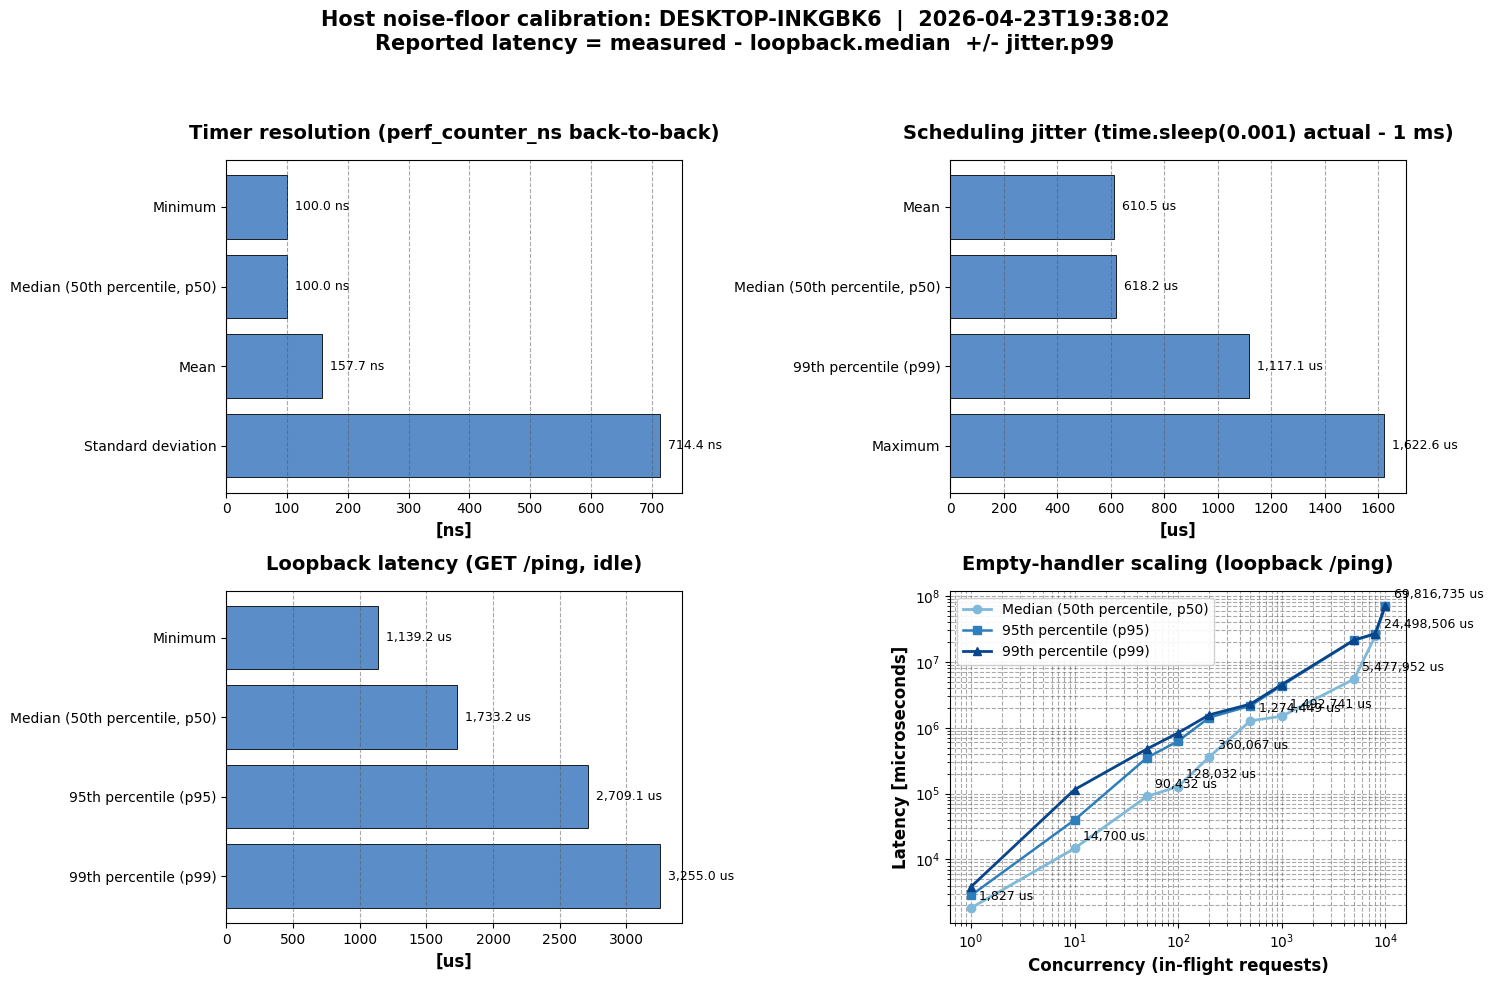

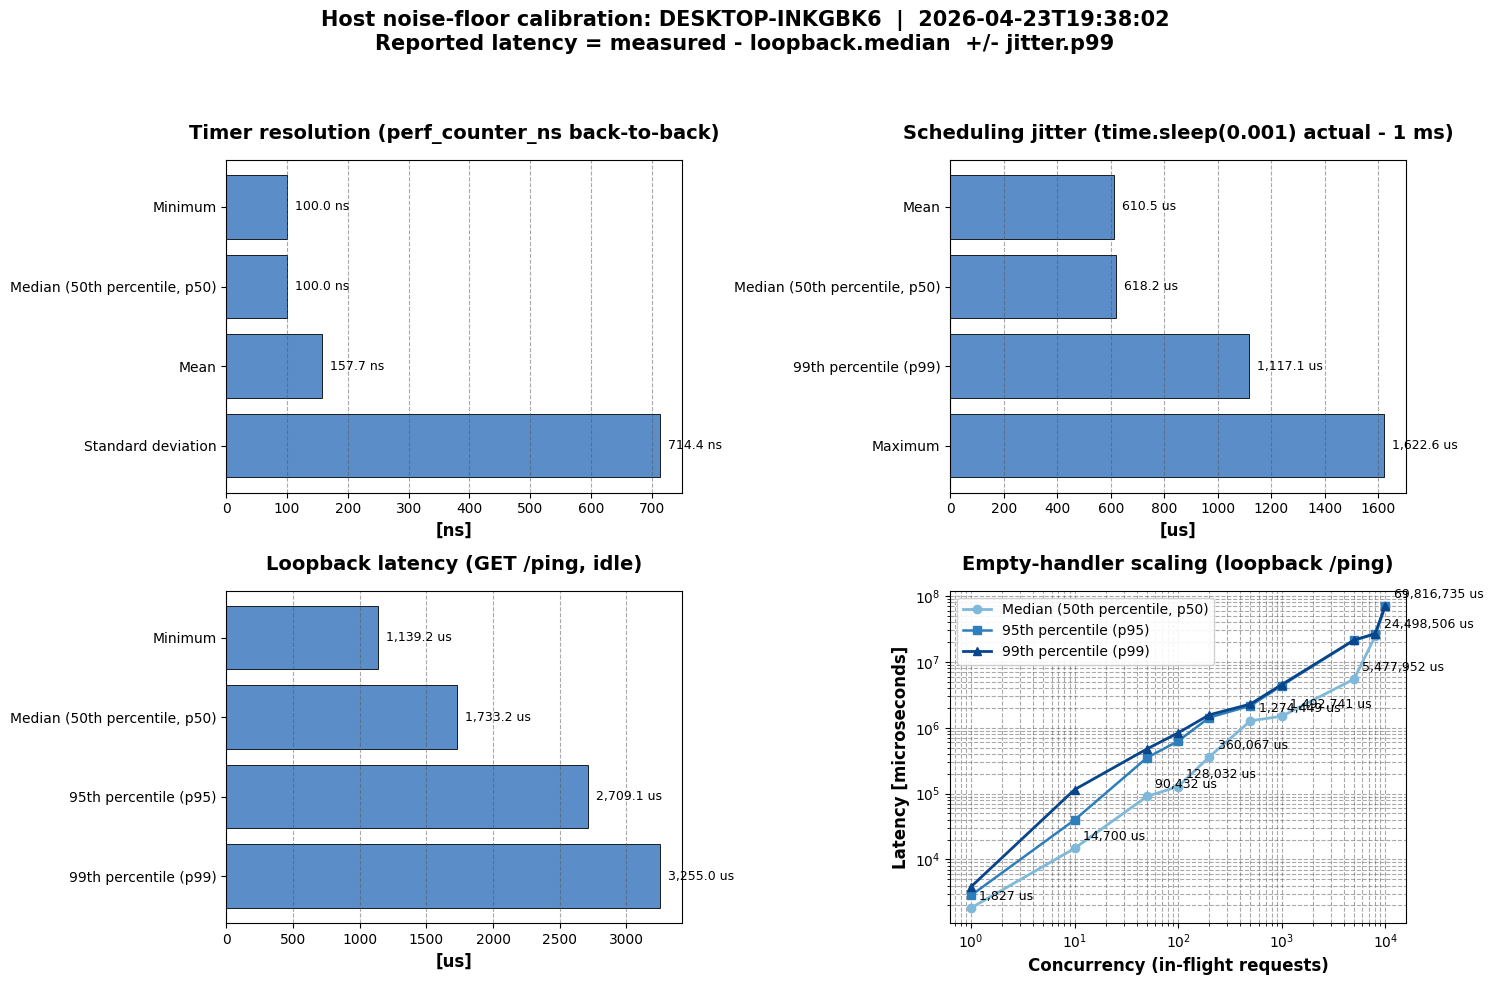

In [6]:
plot_calib_dashboard(
    _envelope,
    file_path=str(_IMG_ROOT),
    fname="dashboard.png",
)

## 6. Handler-scaling detail

Standalone line plot: median (p50), 95th percentile (p95), 99th percentile (p99) vs concurrency. Log-log axes so the span from c=1 to c=100 is legible.

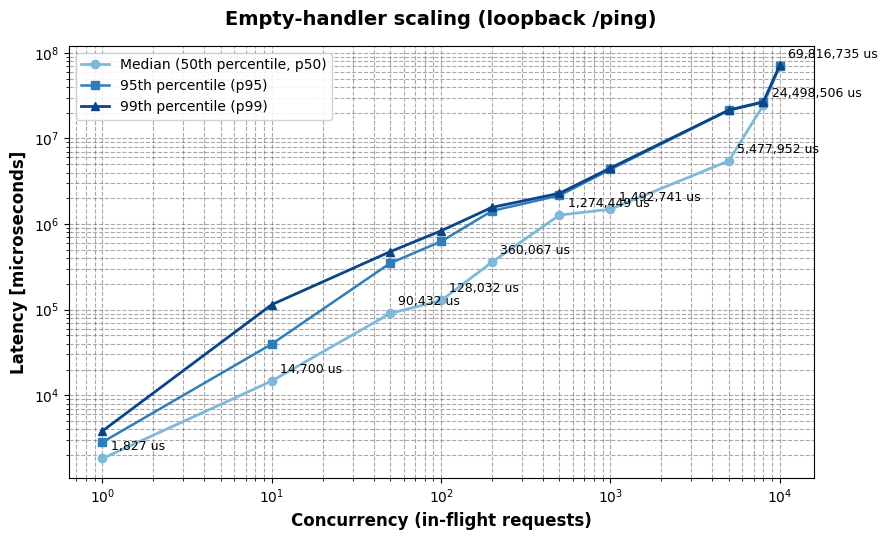

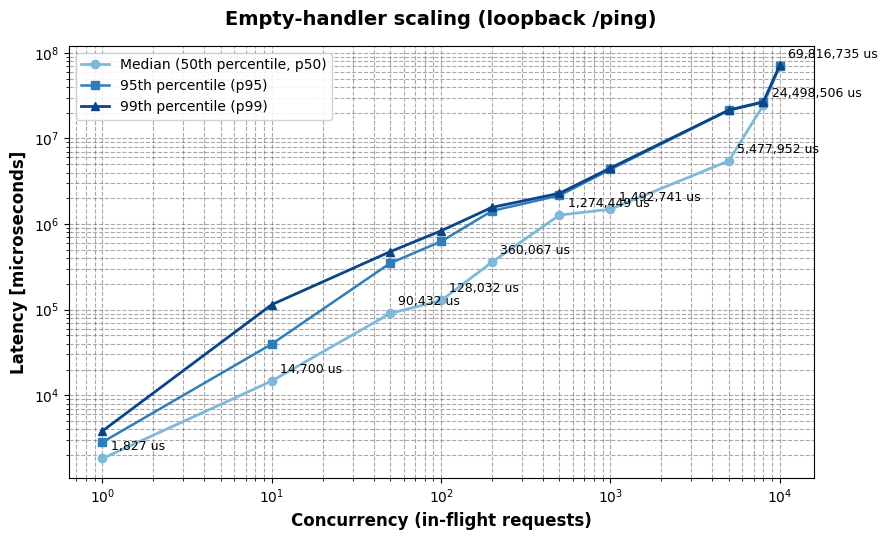

In [7]:
plot_calib_scaling(
    _envelope.get("handler_scaling", {}),
    file_path=str(_IMG_ROOT),
    fname="scaling.png",
)

## 7. Apply the baseline to experiment results

The two numbers that matter when reporting later experiments on this host:

In [8]:
_floor = float(_loopback.get("median_us", 0.0))
_band = float(_jitter.get("p99_us", 0.0))
print(f"Loopback median (host overhead) : {_floor:,.1f} us")
print(f"Jitter p99 (uncertainty band)   : {_band:,.1f} us")
print()
print("Example: a measured experiment latency of 8300 us reports as:")
print(f"  {8300 - _floor:,.1f} us  +/- {_band:,.1f} us")
print()
print("Any measured latency below the host overhead is an instrument error.")

Loopback median (host overhead) : 1,733.2 us
Jitter p99 (uncertainty band)   : 1,117.1 us

Example: a measured experiment latency of 8300 us reports as:
  6,566.8 us  +/- 1,117.1 us

Any measured latency below the host overhead is an instrument error.


## Summary

Run this notebook before every fresh `05-experimental.ipynb` / `06-yoly-experimental.ipynb` session so the downstream cells can load the latest calibration JSON by timestamp. A stale baseline is fine for iteration; a dissertation-quality run pairs every experiment result with a same-session calibration.

**Next in the pipeline**: `05-experimental.ipynb` (fixed-point per-adaptation execution) and `06-yoly-experimental.ipynb` (configuration-sweep yoly).